# From Ideal k-Space to Real MRI Data

**DELTA DIY MRI Workshop — Reconstruction Team**

## Milestone

In Notebook 1, we learned how MRI acquires spatial-frequency information and how a complete k-space dataset can be reconstructed into an image.

Our reconstruction followed:

$$
\boxed{
S(k_x,k_y)
\xrightarrow{\mathrm{IFFT2}}
\rho(x,y)
}
$$

But our k-space was **ideal**:

- fully sampled;
- noise-free;
- generated from a known numerical phantom;
- reconstructed using an ideal spatial-encoding model.

Real MRI data are rarely this perfect.

In this notebook, we will deliberately modify k-space and observe what happens to the reconstructed image.

Our experimental workflow will be:

$$
\boxed{
\text{k-space}
\rightarrow
\text{modify}
\rightarrow
\text{reconstruct}
\rightarrow
\text{observe}
\rightarrow
\text{explain}
}
$$

Finally, we will apply what we learn to **real phantom k-space acquired on a 47 mT MRI scanner**.

## Learning objectives

After completing this notebook, you should be able to:

- relate different regions of k-space to spatial-frequency content;
- explain how limiting k-space extent affects spatial resolution;
- distinguish between $k_{\max}$ and $\Delta k$;
- recognize aliasing caused by phase-encoding undersampling;
- understand how measurement noise affects reconstructed images;
- apply simple image-domain denoising;
- recognize the trade-off between noise suppression and detail preservation;
- inspect and reconstruct real MRI k-space;
- distinguish between incomplete k-space and imperfect spatial encoding;
- identify geometric distortion in a real phantom reconstruction.

## Visualization convention

Throughout this notebook, we will use a consistent visual language:

- **colored data:** k-space / Fourier domain;
- **orange:** selected or retained k-space region;
- **cyan:** acquired k-space lines;
- **black:** missing or unselected samples;
- **grayscale:** reconstructed spatial-domain image.

This helps us distinguish visually between:

$$
\boxed{\text{what was measured}}
$$

and

$$
\boxed{\text{what was reconstructed}}.
$$

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap

# --------------------------------------------------
# Visualization convention
# --------------------------------------------------

KSPACE_CMAP = "viridis"
IMAGE_CMAP = "gray"

MASK_COLOR = "tab:orange"
LINE_COLOR = "cyan"

mask_cmap = ListedColormap(
    [
        "black",
        MASK_COLOR
    ]
)

sampling_cmap = ListedColormap(
    [
        "black",
        LINE_COLOR
    ]
)

# 1. Start With Ideal k-Space

Before deliberately creating problems, we need a reference.

We will use the same numerical phantom from Notebook 1:

- a large circular background;
- two smaller ring-shaped structures;
- complete 2D Cartesian k-space.

This gives us:

$$
\rho_{\mathrm{ref}}(x,y)
$$

and:

$$
S_{\mathrm{ref}}(k_x,k_y).
$$

For every experiment, ask:

> **What did we change in k-space?**

> **What changed in the reconstructed image?**

## 1.1 Create the reference phantom

Because we know the true geometry of this numerical object, changes in:

- shape;
- sharpness;
- spatial detail;
- noise;
- artifacts

are easy to recognize.

Later, we will replace this numerical object with a physical phantom acquired on the 47 mT MRI system.

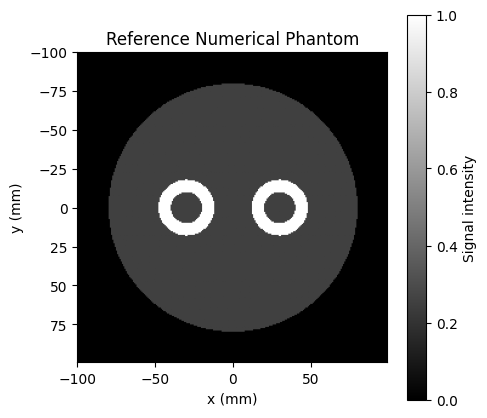

In [18]:
# --------------------------------------------------
# Spatial grid
# --------------------------------------------------

N = 256
FOV = 200  # mm

dx = FOV / N
dy = FOV / N

x = (np.arange(N) - N / 2) * dx
y = (np.arange(N) - N / 2) * dy

X, Y = np.meshgrid(
    x,
    y
)


# --------------------------------------------------
# Numerical phantom
# --------------------------------------------------

phantom = np.zeros(
    (N, N)
)

# Large circular background
background_radius = 80

R_background = np.sqrt(
    X**2 + Y**2
)

phantom[
    R_background <= background_radius
] = 0.25


# Two ring structures
ring_inner_radius = 10
ring_outer_radius = 18

x_left = -30
x_right = 30
y_ring = 0

R_left = np.sqrt(
    (X - x_left)**2
    +
    (Y - y_ring)**2
)

R_right = np.sqrt(
    (X - x_right)**2
    +
    (Y - y_ring)**2
)

left_ring = (
    (R_left >= ring_inner_radius)
    &
    (R_left <= ring_outer_radius)
)

right_ring = (
    (R_right >= ring_inner_radius)
    &
    (R_right <= ring_outer_radius)
)

phantom[left_ring] = 1.0
phantom[right_ring] = 1.0

plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    phantom,
    extent=[
        x[0],
        x[-1],
        y[-1],
        y[0]
    ],
    cmap=IMAGE_CMAP
)

plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("Reference Numerical Phantom")

plt.colorbar(
    label="Signal intensity"
)

plt.show()

## 1.2 Generate complete 2D k-space

From Notebook 1:

$$
\boxed{
\rho(x,y)
\xrightarrow{\mathrm{FFT2}}
S(k_x,k_y)
}
$$

We will calculate the complete k-space representation of the phantom.

This is our **ideal reference dataset**.

kx range: -0.640 to 0.635 cycles/mm
ky range: -0.640 to 0.635 cycles/mm


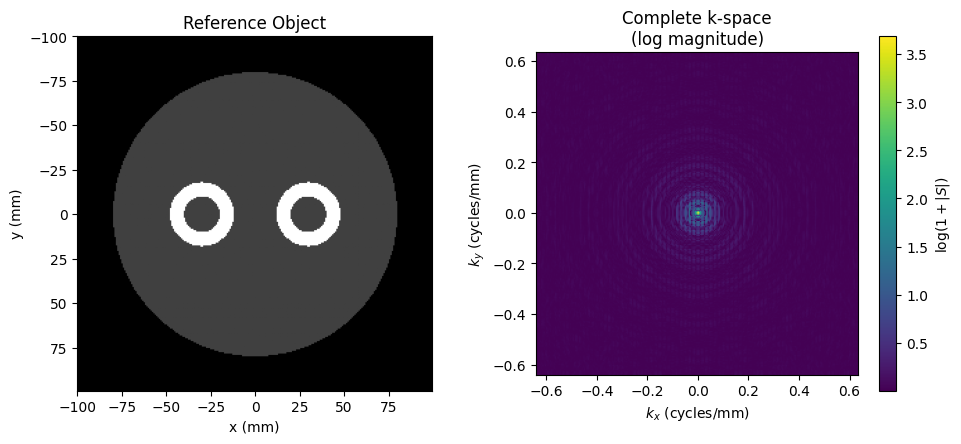

In [19]:
kspace_ref = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(
            phantom
        ),
        norm="ortho"
    )
)

kx = np.fft.fftshift(
    np.fft.fftfreq(
        N,
        d=dx
    )
)

ky = np.fft.fftshift(
    np.fft.fftfreq(
        N,
        d=dy
    )
)

print(
    f"kx range: "
    f"{kx[0]:.3f} to {kx[-1]:.3f} cycles/mm"
)

print(
    f"ky range: "
    f"{ky[0]:.3f} to {ky[-1]:.3f} cycles/mm"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4.5)
)

# Object
axes[0].imshow(
    phantom,
    extent=[
        x[0],
        x[-1],
        y[-1],
        y[0]
    ],
    cmap=IMAGE_CMAP
)

axes[0].set_title(
    "Reference Object"
)

axes[0].set_xlabel(
    "x (mm)"
)

axes[0].set_ylabel(
    "y (mm)"
)


# k-space
im = axes[1].imshow(
    np.log1p(
        np.abs(kspace_ref)
    ),
    extent=[
        kx[0],
        kx[-1],
        ky[0],
        ky[-1]
    ],
    origin="lower",
    cmap=KSPACE_CMAP,
    aspect="equal"
)

axes[1].set_title(
    "Complete k-space\n(log magnitude)"
)

axes[1].set_xlabel(
    r"$k_x$ (cycles/mm)"
)

axes[1].set_ylabel(
    r"$k_y$ (cycles/mm)"
)

fig.colorbar(
    im,
    ax=axes[1],
    label=r"$\log(1+|S|)$"
)

plt.tight_layout()
plt.show()

## 1.3 Establish the reference reconstruction

Complete k-space should reconstruct the expected object:

$$
S_{\mathrm{ref}}(k_x,k_y)
\xrightarrow{\mathrm{IFFT2}}
\rho_{\mathrm{ref}}(x,y).
$$

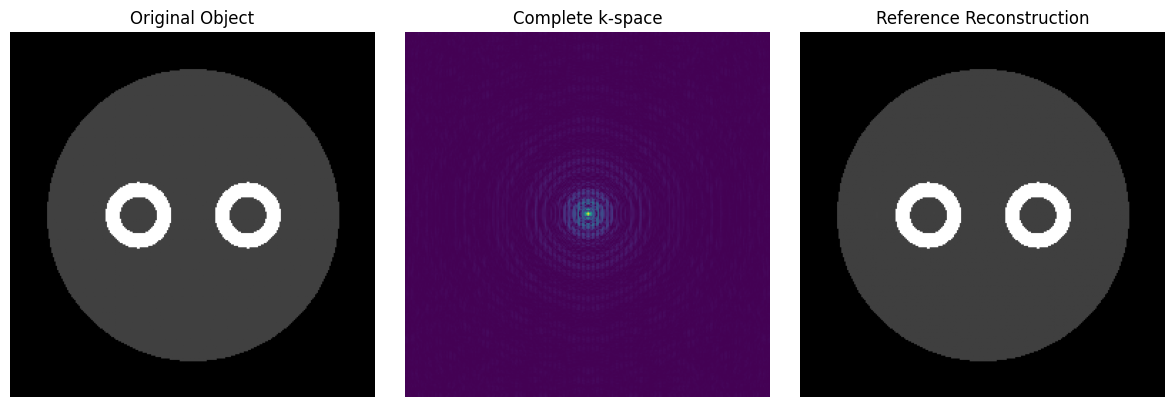

In [20]:
image_ref_complex = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(
            kspace_ref
        ),
        norm="ortho"
    )
)

image_ref = np.abs(
    image_ref_complex
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

axes[0].imshow(
    phantom,
    cmap=IMAGE_CMAP
)
axes[0].set_title(
    "Original Object"
)
axes[0].axis("off")


axes[1].imshow(
    np.log1p(
        np.abs(kspace_ref)
    ),
    cmap=KSPACE_CMAP,
    origin="lower"
)
axes[1].set_title(
    "Complete k-space"
)
axes[1].axis("off")


axes[2].imshow(
    image_ref,
    cmap=IMAGE_CMAP
)
axes[2].set_title(
    "Reference Reconstruction"
)
axes[2].axis("off")


plt.tight_layout()
plt.show()

Our starting point is:

$$
\boxed{
\text{complete ideal k-space}
\rightarrow
\text{accurate reconstruction}
}
$$

Now we can begin changing the data.

Our first question is:

> **Do all spatial frequencies contribute the same type of spatial information?**

# 2. What Information Is Carried by Different Spatial Frequencies?

Our reference k-space contains spatial frequencies ranging approximately from:

$$
-k_{\max}
\quad\text{to}\quad
+k_{\max}.
$$

Recall:

- lower spatial frequencies describe more slowly varying spatial structure;
- higher spatial frequencies allow more rapidly varying spatial structure to be represented.

We will progressively restrict the available spatial-frequency range.

$$
\boxed{
\text{complete k-space}
\rightarrow
\text{limit }k_{\max}
\rightarrow
\mathrm{IFFT2}
\rightarrow
\text{observe}
}
$$

## 2.1 Make a prediction

Suppose we reconstruct the phantom using only spatial frequencies close to:

$$
(k_x,k_y)=(0,0).
$$

Before running the experiment:

> **Will we still recognize the phantom?**

> **What will happen to sharp boundaries?**

> **What happens as progressively higher spatial frequencies are restored?**

## 2.3 Which part of k-space are we keeping?

The colored background represents the actual k-space data.

The **orange region** shows which spatial frequencies are retained.

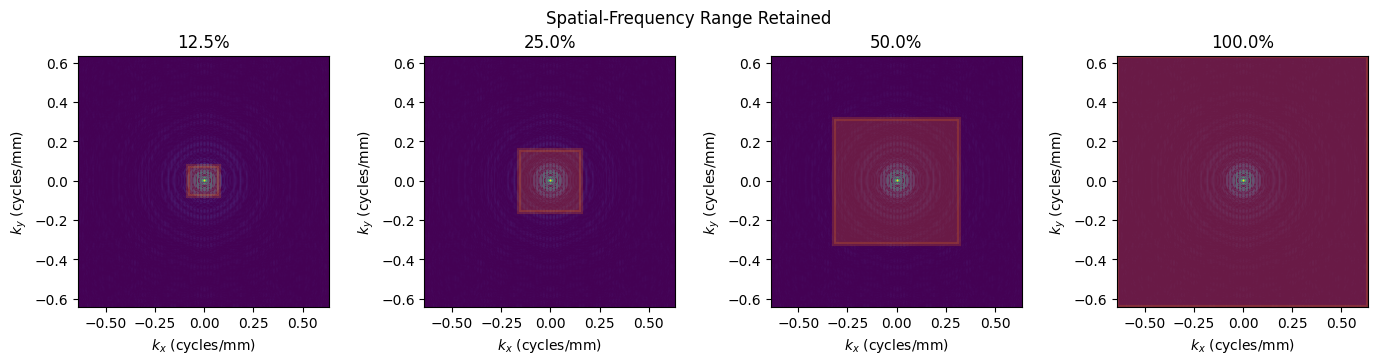

In [21]:
fractions = [
    0.125,
    0.25,
    0.50,
    1.00
]

masks = []
masked_kspaces = []

for fraction in fractions:

    width = int(
        np.round(
            N * fraction
        )
    )

    if width % 2 != 0:
        width += 1

    start = (
        N // 2
        -
        width // 2
    )

    end = (
        start
        +
        width
    )

    mask = np.zeros(
        (N, N),
        dtype=float
    )

    mask[
        start:end,
        start:end
    ] = 1.0

    kspace_masked = (
        kspace_ref
        *
        mask
    )

    masks.append(
        mask
    )

    masked_kspaces.append(
        kspace_masked
    )

fig, axes = plt.subplots(
    1,
    len(fractions),
    figsize=(14, 3.5)
)

for ax, mask, fraction in zip(
    axes,
    masks,
    fractions
):

    ax.imshow(
        np.log1p(
            np.abs(kspace_ref)
        ),
        extent=[
            kx[0],
            kx[-1],
            ky[0],
            ky[-1]
        ],
        origin="lower",
        cmap=KSPACE_CMAP,
        aspect="equal"
    )

    rows, cols = np.where(
        mask > 0
    )

    kx_min = kx[
        cols.min()
    ]

    kx_max = kx[
        cols.max()
    ]

    ky_min = ky[
        rows.min()
    ]

    ky_max = ky[
        rows.max()
    ]

    rectangle = plt.Rectangle(
        (kx_min, ky_min),
        kx_max - kx_min,
        ky_max - ky_min,
        facecolor=MASK_COLOR,
        edgecolor=MASK_COLOR,
        alpha=0.20,
        linewidth=3
    )

    ax.add_patch(
        rectangle
    )

    ax.set_title(
        f"{fraction * 100:.1f}%"
    )

    ax.set_xlabel(
        r"$k_x$ (cycles/mm)"
    )

    ax.set_ylabel(
        r"$k_y$ (cycles/mm)"
    )

plt.suptitle(
    "Spatial-Frequency Range Retained"
)

plt.tight_layout()
plt.show()

As the orange region expands, progressively larger values of:

$$
|k_x|
\quad\text{and}\quad
|k_y|
$$

are included.

Now let's look at the actual data remaining after the mask is applied.

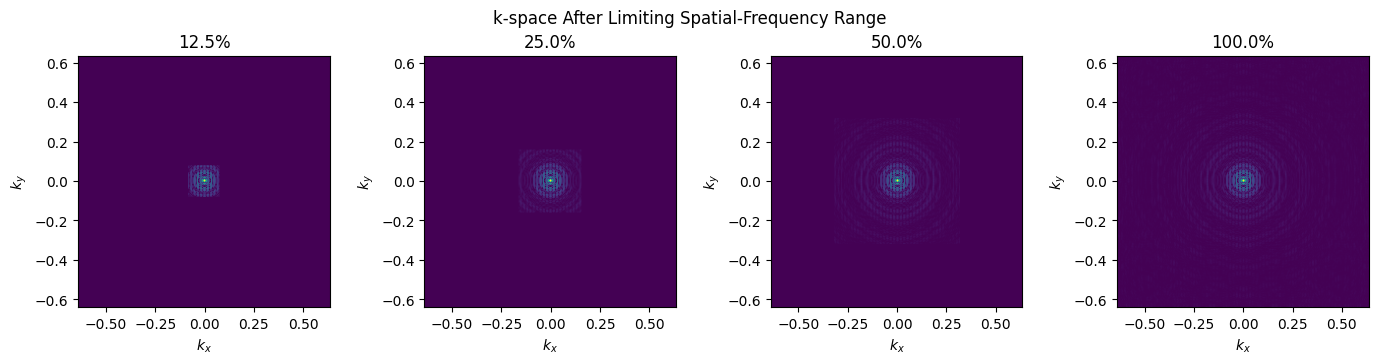

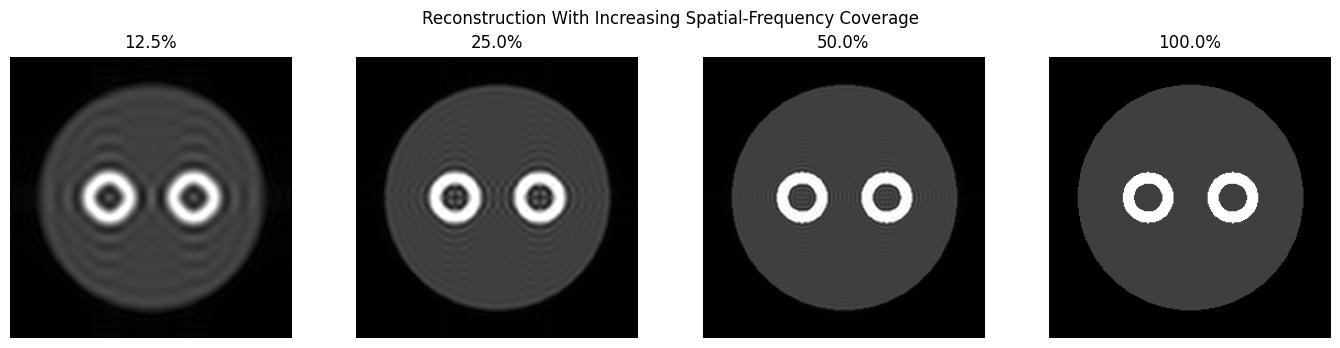

In [23]:
fig, axes = plt.subplots(
    1,
    len(fractions),
    figsize=(14, 3.5)
)

for ax, kspace_modified, fraction in zip(
    axes,
    masked_kspaces,
    fractions
):

    ax.imshow(
        np.log1p(
            np.abs(kspace_modified)
        ),
        extent=[
            kx[0],
            kx[-1],
            ky[0],
            ky[-1]
        ],
        origin="lower",
        cmap=KSPACE_CMAP,
        aspect="equal"
    )

    ax.set_title(
        f"{fraction * 100:.1f}%"
    )

    ax.set_xlabel(
        r"$k_x$"
    )

    ax.set_ylabel(
        r"$k_y$"
    )

plt.suptitle(
    "k-space After Limiting Spatial-Frequency Range"
)

plt.tight_layout()
plt.show()

limited_recons = []

for kspace_modified in masked_kspaces:

    recon = np.fft.fftshift(
        np.fft.ifft2(
            np.fft.ifftshift(
                kspace_modified
            ),
            norm="ortho"
        )
    )

    limited_recons.append(
        np.abs(recon)
    )

fig, axes = plt.subplots(
    1,
    len(fractions),
    figsize=(14, 3.5)
)

for ax, recon, fraction in zip(
    axes,
    limited_recons,
    fractions
):

    ax.imshow(
        recon,
        cmap=IMAGE_CMAP,
        vmin=0,
        vmax=np.max(image_ref)
    )

    ax.set_title(
        f"{fraction * 100:.1f}%"
    )

    ax.axis("off")

plt.suptitle(
    "Reconstruction With Increasing Spatial-Frequency Coverage"
)

plt.tight_layout()
plt.show()

## 2.4 What changed?

With a limited spatial-frequency range:

- boundaries become less sharp;
- small structures become harder to distinguish;
- fine spatial detail is lost.

As progressively higher spatial frequencies are included:

- boundaries become sharper;
- the rings become better defined;
- the reconstruction approaches the reference image.

Therefore:

$$
\boxed{
\text{larger spatial-frequency extent}
\rightarrow
\text{ability to represent finer spatial detail}
}
$$

## 2.5 Connect $k_{\max}$ to spatial resolution

For Cartesian sampling, nominal spatial resolution is approximately:

$$
\Delta x
\approx
\frac{1}{2k_{x,\max}}
$$

and:

$$
\Delta y
\approx
\frac{1}{2k_{y,\max}}.
$$

Therefore:

$$
k_{\max}\downarrow
\quad\Longrightarrow\quad
\Delta x\uparrow.
$$

In [24]:
print(
    f"Original pixel size: "
    f"{dx:.3f} mm\n"
)

for fraction, mask in zip(
    fractions,
    masks
):

    retained_columns = np.where(
        np.any(
            mask > 0,
            axis=0
        )
    )[0]

    kmax_retained = np.max(
        np.abs(
            kx[
                retained_columns
            ]
        )
    )

    resolution = (
        1
        /
        (
            2
            *
            kmax_retained
        )
    )

    print(
        f"{fraction * 100:5.1f}% coverage: "
        f"kmax = {kmax_retained:.4f} cycles/mm, "
        f"nominal resolution ≈ {resolution:.2f} mm"
    )

Original pixel size: 0.781 mm

 12.5% coverage: kmax = 0.0800 cycles/mm, nominal resolution ≈ 6.25 mm
 25.0% coverage: kmax = 0.1600 cycles/mm, nominal resolution ≈ 3.12 mm
 50.0% coverage: kmax = 0.3200 cycles/mm, nominal resolution ≈ 1.56 mm
100.0% coverage: kmax = 0.6400 cycles/mm, nominal resolution ≈ 0.78 mm


## 2.6 Notice the ringing

The strongest truncation may also produce oscillations near sharp boundaries.

Our mask changes abruptly from:

$$
1\rightarrow0.
$$

Therefore:

$$
S_{\mathrm{modified}}
=
S_{\mathrm{ref}}M.
$$

An abrupt cutoff in spatial-frequency space can produce ringing near sharp image boundaries.

Thus this experiment demonstrates:

$$
\boxed{
k_{\max}\downarrow
\rightarrow
\text{coarser resolution}
}
$$

and:

$$
\boxed{
\text{abrupt truncation}
\rightarrow
\text{ringing}
}
$$

# Checkpoint

In this experiment, we reduced:

$$
k_{\max}.
$$

We did **not** primarily change the spacing between neighboring k-space samples.

Next we will perform a different experiment:

> **Keep approximately the same spatial-frequency extent, but acquire fewer phase-encoding lines.**

# 3. What Happens When We Undersample k-Space?

Recall from Notebook 1:

$$
\boxed{
\text{one phase-encoding step}
\rightarrow
\text{one }k_x\text{ readout at a particular }k_y
}
$$

A complete Cartesian acquisition fills:

$$
k_{y,1},
k_{y,2},
k_{y,3},
\dots
$$

But what happens if some phase-encoding steps are skipped?

## 3.1 Limited extent versus undersampling

### Section 2

We reduced:

$$
k_{\max}.
$$

Main consequence:

$$
\boxed{
\text{reduced spatial resolution}
}
$$

### Section 3

Now we increase the spacing between acquired phase-encoding lines:

$$
\Delta k_y\uparrow
$$

while keeping approximately the same spatial-frequency extent.

The question is:

> **Will the image simply become blurrier, or will something different happen?**

## 3.2 Skip phase-encoding lines

We will compare:

- fully sampled k-space;
- every second $k_y$ line;
- every fourth $k_y$ line.

The $k_x$ readout remains fully sampled.

We will also make sure that the central $k_y=0$ line is always retained.

In [25]:
acceleration_factors = [
    1,
    2,
    4
]

undersampling_masks = []
undersampled_kspaces = []

center_row = N // 2
row_indices = np.arange(N)

for R in acceleration_factors:

    mask = np.zeros(
        (N, N),
        dtype=float
    )

    acquired_rows = (
        (row_indices - center_row) % R
        == 0
    )

    mask[
        acquired_rows,
        :
    ] = 1.0

    kspace_under = (
        kspace_ref
        *
        mask
    )

    undersampling_masks.append(
        mask
    )

    undersampled_kspaces.append(
        kspace_under
    )



### Why do we keep the original matrix size?

Notice that the undersampled k-space is still stored in an $N\times N$ array.

We did not make the array smaller.

Instead:

- acquired $k_y$ lines contain measured data;
- unacquired locations are represented by zeros.

For example:

```text
Fully sampled

████████████
████████████
████████████
████████████
████████████


2× undersampled

████████████
............
████████████
............
████████████


## 3.3 Which phase-encoding lines are acquired?

The colored background represents the complete k-space.

The **cyan horizontal lines** identify the $k_y$ locations that are acquired.

Watch how the spacing between neighboring acquired lines changes.

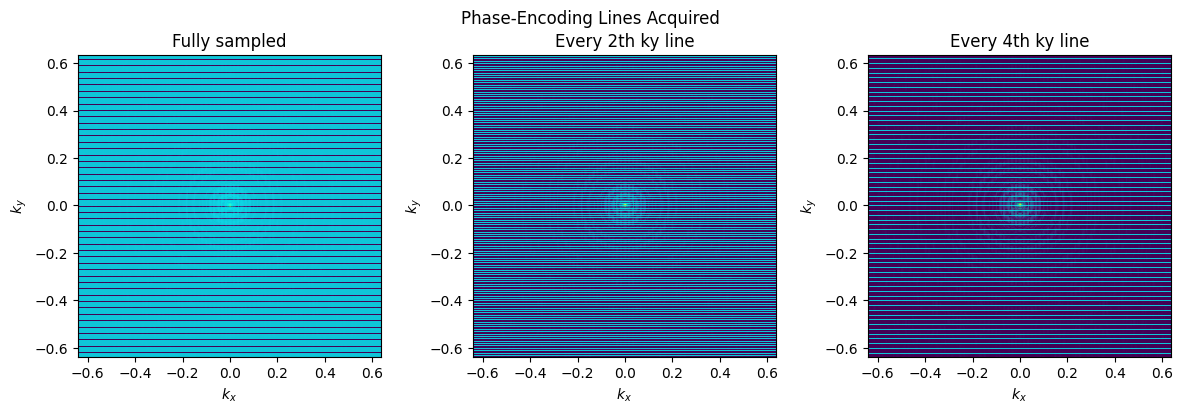

In [26]:
fig, axes = plt.subplots(
    1,
    len(acceleration_factors),
    figsize=(12, 4)
)

for ax, mask, R in zip(
    axes,
    undersampling_masks,
    acceleration_factors
):

    ax.imshow(
        np.log1p(
            np.abs(kspace_ref)
        ),
        extent=[
            kx[0],
            kx[-1],
            ky[0],
            ky[-1]
        ],
        origin="lower",
        cmap=KSPACE_CMAP,
        aspect="equal"
    )

    acquired_rows = np.where(
        np.any(
            mask > 0,
            axis=1
        )
    )[0]

    for row in acquired_rows:

        ax.axhline(
            ky[row],
            color=LINE_COLOR,
            linewidth=0.7,
            alpha=0.8
        )

    if R == 1:
        title = "Fully sampled"
    else:
        title = f"Every {R}th ky line"

    ax.set_title(
        title
    )

    ax.set_xlabel(
        r"$k_x$"
    )

    ax.set_ylabel(
        r"$k_y$"
    )

plt.suptitle(
    "Phase-Encoding Lines Acquired"
)

plt.tight_layout()
plt.show()

For the fully sampled acquisition:

$$
\Delta k_y.
$$

If every second line is acquired:

$$
\Delta k_y'
=
2\Delta k_y.
$$

If every fourth line is acquired:

$$
\Delta k_y'
=
4\Delta k_y.
$$

Now let's look at the actual acquired data.

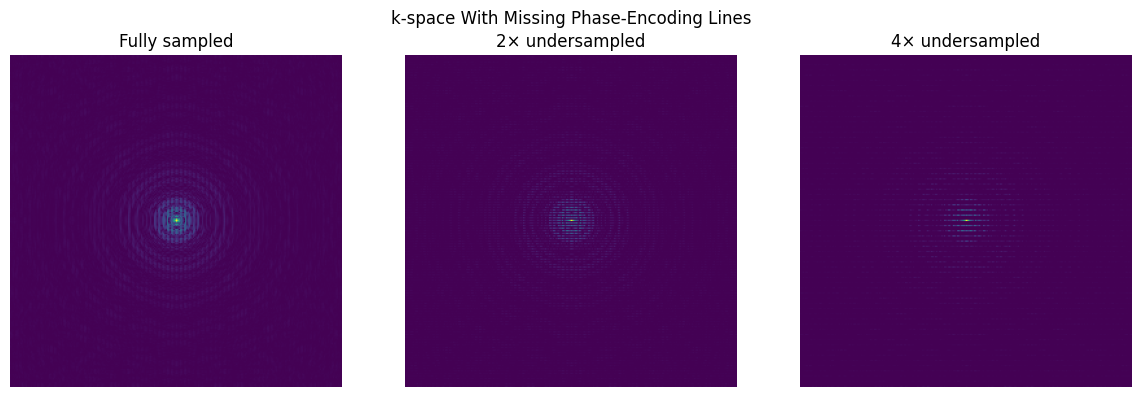

In [27]:
fig, axes = plt.subplots(
    1,
    len(acceleration_factors),
    figsize=(12, 4)
)

for ax, kspace_under, R in zip(
    axes,
    undersampled_kspaces,
    acceleration_factors
):

    ax.imshow(
        np.log1p(
            np.abs(kspace_under)
        ),
        cmap=KSPACE_CMAP,
        origin="lower"
    )

    if R == 1:
        title = "Fully sampled"
    else:
        title = f"{R}× undersampled"

    ax.set_title(
        title
    )

    ax.axis("off")

plt.suptitle(
    "k-space With Missing Phase-Encoding Lines"
)

plt.tight_layout()
plt.show()

Before reconstructing, make a prediction.

We still sample approximately the same maximum spatial frequency:

$$
k_{y,\max}.
$$

But:

$$
\Delta k_y\uparrow.
$$

What will happen to the image?

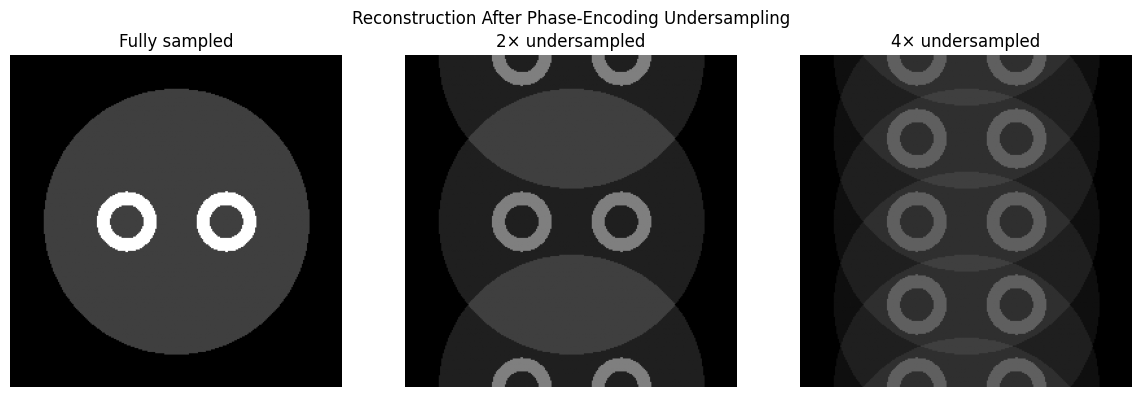

In [28]:
undersampled_recons = []

for kspace_under in undersampled_kspaces:

    recon = np.fft.fftshift(
        np.fft.ifft2(
            np.fft.ifftshift(
                kspace_under
            ),
            norm="ortho"
        )
    )

    undersampled_recons.append(
        np.abs(recon)
    )

fig, axes = plt.subplots(
    1,
    len(acceleration_factors),
    figsize=(12, 4)
)

for ax, recon, R in zip(
    axes,
    undersampled_recons,
    acceleration_factors
):

    ax.imshow(
        recon,
        cmap=IMAGE_CMAP,
        vmin=0,
        vmax=np.max(image_ref)
    )

    if R == 1:
        title = "Fully sampled"
    else:
        title = f"{R}× undersampled"

    ax.set_title(
        title
    )

    ax.axis("off")

plt.suptitle(
    "Reconstruction After Phase-Encoding Undersampling"
)

plt.tight_layout()
plt.show()

## 3.4 Aliasing

Unlike the limited-$k_{\max}$ experiment, the object does not simply become smoother.

Instead, structures are replicated and overlap along the phase-encoding direction.

This is:

$$
\boxed{
\text{aliasing}
}
$$

or **wrap-around**.

The field of view is related to k-space sampling interval by:

$$
\boxed{
\mathrm{FOV}_y
=
\frac{1}{\Delta k_y}
}
$$

Therefore:

$$
\Delta k_y\uparrow
\quad\Longrightarrow\quad
\mathrm{FOV}_y\downarrow.
$$

## 3.5 Resolution and FOV come from different properties of k-space

### Spatial-frequency extent

$$
k_{\max}
$$

controls nominal spatial resolution:

$$
\boxed{
\Delta x
\approx
\frac{1}{2k_{\max}}
}
$$

### Spatial-frequency sampling interval

$$
\Delta k
$$

controls field of view:

$$
\boxed{
\mathrm{FOV}
=
\frac{1}{\Delta k}
}
$$

Therefore:

| k-space change | Main consequence |
|---|---|
| Reduce $k_{\max}$ | Coarser spatial resolution |
| Increase $\Delta k$ | Smaller unaliased FOV / aliasing |

## 3.6 Connect undersampling to scan time

For conventional Cartesian imaging:

$$
T_{\mathrm{scan}}
\propto
N_{PE}\times TR.
$$

Therefore:

$$
N_{PE}\downarrow
\quad\Longrightarrow\quad
T_{\mathrm{scan}}\downarrow.
$$

Acquiring fewer phase-encoding lines can make MRI faster.

But simply skipping lines and applying a Fourier reconstruction produces aliasing.

More advanced approaches such as parallel imaging and compressed sensing use additional information or reconstruction constraints to recover images from undersampled measurements.

# Checkpoint

We have now created two different k-space problems:

$$
\boxed{
k_{\max}\downarrow
\rightarrow
\text{coarser resolution}
}
$$

and:

$$
\boxed{
\Delta k\uparrow
\rightarrow
\text{aliasing}
}
$$

So far, however, every acquired sample has been measured perfectly.

Real MRI measurements contain noise.

# 4. Noise and Denoising

Real MRI measurements contain noise from sources including:

- receive electronics;
- RF coils;
- the sample;
- thermal fluctuations.

For complex MRI data, a simple model is:

$$
S_{\mathrm{noisy}}
=
S+n
$$

where:

$$
n
=
n_{\mathrm{real}}
+
i n_{\mathrm{imag}}.
$$

We will add controlled complex Gaussian noise to our simulated k-space and observe how it propagates into the reconstructed image.

## 4.1 Add complex noise to k-space

For this teaching experiment, noise amplitude is specified relative to the maximum magnitude of the simulated k-space.

The values below are therefore **illustrative noise levels**, not measured SNR values.

In [29]:
rng = np.random.default_rng(
    42
)

signal_scale = np.max(
    np.abs(kspace_ref)
)

noise_levels = [
    0.00,
    0.01,
    0.03,
    0.06
]

noisy_kspaces = []

for noise_level in noise_levels:

    sigma = (
        noise_level
        *
        signal_scale
    )

    noise = sigma * (
        rng.standard_normal(
            kspace_ref.shape
        )
        +
        1j
        *
        rng.standard_normal(
            kspace_ref.shape
        )
    )

    kspace_noisy = (
        kspace_ref
        +
        noise
    )

    noisy_kspaces.append(
        kspace_noisy
    )

Let's first inspect the noisy k-space.

Because the k-space signal spans a large dynamic range, we display:

$$
\log(1+|S|).
$$

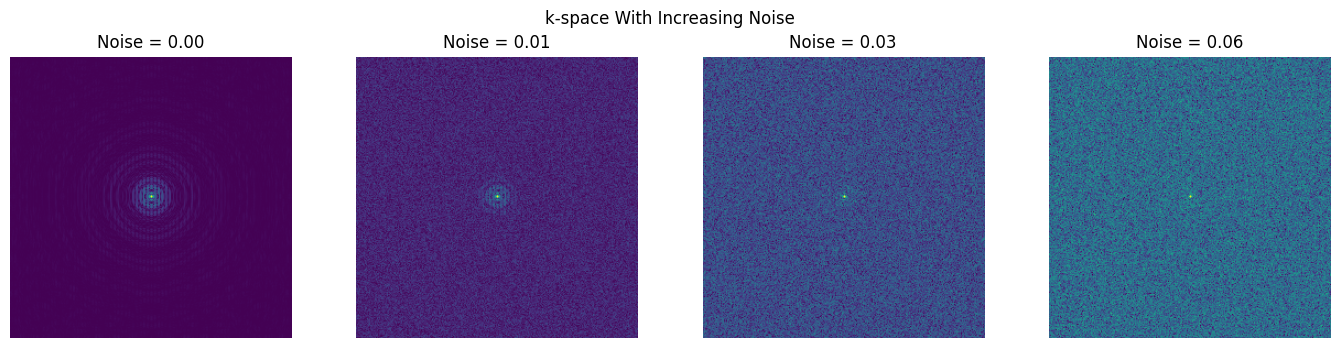

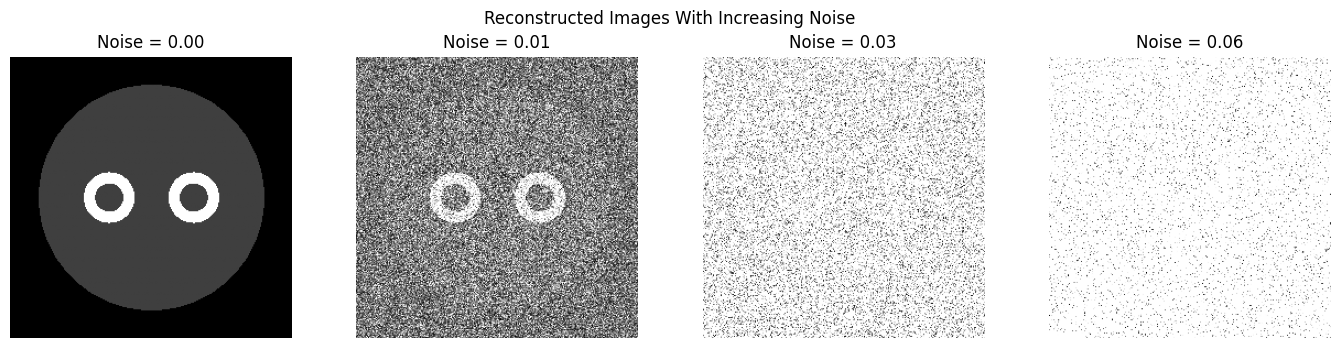

In [31]:
fig, axes = plt.subplots(
    1,
    len(noise_levels),
    figsize=(14, 3.5)
)

for ax, kspace_noisy, noise_level in zip(
    axes,
    noisy_kspaces,
    noise_levels
):

    ax.imshow(
        np.log1p(
            np.abs(kspace_noisy)
        ),
        cmap=KSPACE_CMAP,
        origin="lower"
    )

    ax.set_title(
        f"Noise = {noise_level:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "k-space With Increasing Noise"
)

plt.tight_layout()
plt.show()

noisy_recons = []

for kspace_noisy in noisy_kspaces:

    recon = np.fft.fftshift(
        np.fft.ifft2(
            np.fft.ifftshift(
                kspace_noisy
            ),
            norm="ortho"
        )
    )

    noisy_recons.append(
        np.abs(recon)
    )

fig, axes = plt.subplots(
    1,
    len(noise_levels),
    figsize=(14, 3.5)
)

for ax, recon, noise_level in zip(
    axes,
    noisy_recons,
    noise_levels
):

    ax.imshow(
        recon,
        cmap=IMAGE_CMAP,
        vmin=0,
        vmax=np.max(image_ref)
    )

    ax.set_title(
        f"Noise = {noise_level:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "Reconstructed Images With Increasing Noise"
)

plt.tight_layout()
plt.show()

## 4.2 What changed?

As noise increases:

- the background becomes less uniform;
- object boundaries become harder to identify;
- weak structures become harder to distinguish;
- apparent image quality decreases.

The underlying object itself has not changed.

Only the measurement quality has changed.

## 4.3 Can we reduce the noise?

A simple approach is spatial smoothing.

For example:

$$
\rho_{\mathrm{denoised}}
=
\rho_{\mathrm{noisy}}
*
h_{\mathrm{Gaussian}}.
$$

This suppresses rapidly varying image components.

But there is a problem.

Sharp boundaries and small structures also contain rapidly varying spatial information.

Therefore:

$$
\boxed{
\text{noise reduction is not free}
}
$$

## 4.4 Apply Gaussian denoising

We will take the noisiest reconstruction and apply several smoothing strengths.

The Gaussian parameter $\sigma$ controls the amount of smoothing.

Larger $\sigma$ means stronger smoothing.

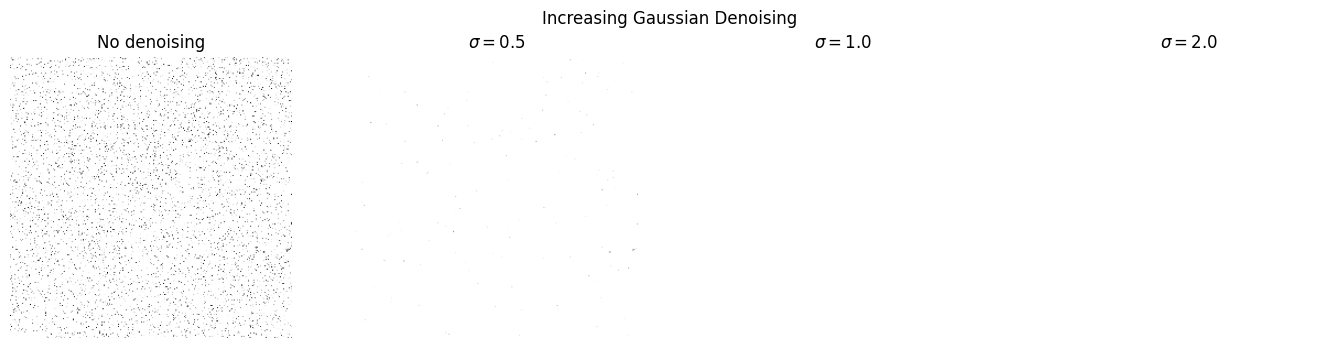

In [32]:
noisy_image = noisy_recons[
    -1
]

sigma_values = [
    0,
    0.5,
    1.0,
    2.0
]

denoised_images = []

for sigma in sigma_values:

    if sigma == 0:

        filtered = (
            noisy_image.copy()
        )

    else:

        filtered = gaussian_filter(
            noisy_image,
            sigma=sigma
        )

    denoised_images.append(
        filtered
    )

fig, axes = plt.subplots(
    1,
    len(sigma_values),
    figsize=(14, 3.5)
)

for ax, image, sigma in zip(
    axes,
    denoised_images,
    sigma_values
):

    ax.imshow(
        image,
        cmap=IMAGE_CMAP,
        vmin=0,
        vmax=np.max(image_ref)
    )

    if sigma == 0:
        title = "No denoising"

    else:
        title = rf"$\sigma={sigma}$"

    ax.set_title(
        title
    )

    ax.axis("off")

plt.suptitle(
    "Increasing Gaussian Denoising"
)

plt.tight_layout()
plt.show()

With mild smoothing:

- random fluctuations decrease;
- background uniformity improves;
- the object may become easier to recognize.

With stronger smoothing:

- noise decreases further;
- boundaries become less sharp;
- fine structural information begins to disappear.

Therefore:

$$
\boxed{
\text{more smoothing}
\rightarrow
\text{less noise}
}
$$

but also:

$$
\boxed{
\text{more smoothing}
\rightarrow
\text{less spatial detail}
}
$$

## 4.5 Inspect a line profile

An image may look smoother even when meaningful spatial information has been altered.

Let's inspect a horizontal line through the two rings.

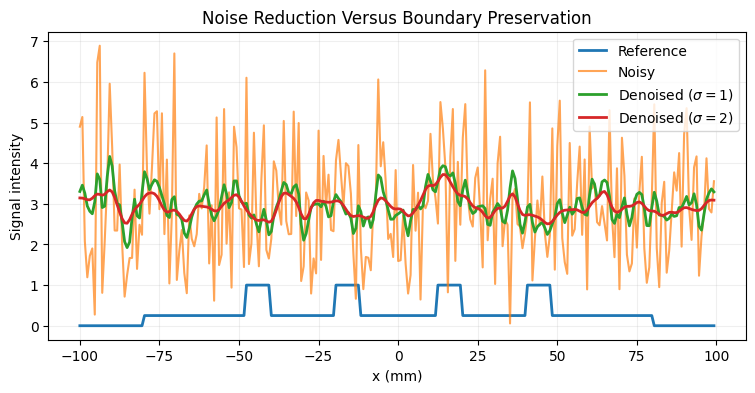

In [33]:
iy_center = np.argmin(
    np.abs(
        y
    )
)

plt.figure(
    figsize=(9, 4)
)

plt.plot(
    x,
    image_ref[
        iy_center,
        :
    ],
    linewidth=2,
    label="Reference"
)

plt.plot(
    x,
    noisy_image[
        iy_center,
        :
    ],
    alpha=0.7,
    label="Noisy"
)

plt.plot(
    x,
    denoised_images[2][
        iy_center,
        :
    ],
    linewidth=2,
    label=r"Denoised ($\sigma=1$)"
)

plt.plot(
    x,
    denoised_images[3][
        iy_center,
        :
    ],
    linewidth=2,
    label=r"Denoised ($\sigma=2$)"
)

plt.xlabel(
    "x (mm)"
)

plt.ylabel(
    "Signal intensity"
)

plt.title(
    "Noise Reduction Versus Boundary Preservation"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

A useful denoising method should ideally:

$$
\boxed{
\text{reduce unwanted noise}
\quad\text{while preserving true structure}
}
$$

A smoother image is therefore **not automatically a better image**.

This reconnects us to Section 2:

Gaussian smoothing suppresses higher spatial-frequency components.

Some of those components may represent noise, but some represent real boundaries and fine spatial structure.

# Checkpoint

We have now encountered three reconstruction problems:

### Limited spatial-frequency extent

$$
k_{\max}\downarrow
\rightarrow
\text{coarser resolution}
$$

### Undersampling

$$
\Delta k\uparrow
\rightarrow
\text{aliasing}
$$

### Measurement noise

$$
S
\rightarrow
S+n
\rightarrow
\text{noisy reconstruction}
$$

We also learned that denoising introduces a trade-off:

$$
\boxed{
\text{noise suppression}
\leftrightarrow
\text{detail preservation}
}
$$

Until now, however, we knew exactly what the object should look like.

Now we will move to **real MRI data**.

# 5. Reconstruction Challenge: Real 47 mT MRI Data

You now have the tools needed to work with real MRI k-space.

In the previous sections, you learned how different problems affect the reconstructed image:

$$
\boxed{
k_{\max}\downarrow
\rightarrow
\text{coarser spatial resolution}
}
$$

$$
\boxed{
\Delta k\uparrow
\rightarrow
\text{aliasing}
}
$$

$$
\boxed{
\text{measurement noise}
\rightarrow
\text{noisy reconstruction}
}
$$

Now you will work with a **real phantom dataset acquired on a 47 mT MRI scanner**.

Your task is to develop the reconstruction yourself.

---

## Your challenge

Starting from the provided NumPy file containing the measured k-space:

1. Load the dataset.
2. Inspect the array dimensions and data type.
3. Determine how the complex k-space data are stored.
4. Visualize the k-space magnitude.
5. Decide whether a logarithmic display is useful.
6. Reconstruct the image using the appropriate Fourier transform.
7. Display the reconstructed magnitude image.
8. Inspect the image for unexpected features or artifacts.
9. Compare the reconstructed geometry with the known physical phantom.
10. Based on what you learned earlier, propose possible explanations for what you observe.

---

### Questions to guide your investigation

As you work, ask:

> **Does the k-space look complete?**

> **Is the strongest signal located where you expect?**

> **Do you see missing or unusually bright lines?**

> **Does the reconstructed image show blurring, ringing, aliasing, noise, or something else?**

> **Does the shape of the reconstructed phantom match the physical phantom?**

> **Could the problem originate from the spatial encoding rather than from missing k-space samples?**

---

Your goal is not only to produce an image.

Your goal is to understand:

$$
\boxed{
\text{what the data are telling you about the MRI system}
}
$$

In [ ]:
# Load the 47 mT k-space data

# Inspect the array

# Visualize k-space

# Reconstruct the image

# Display and inspect the reconstruction